## **DATA UNDERSTANDING PHASE**

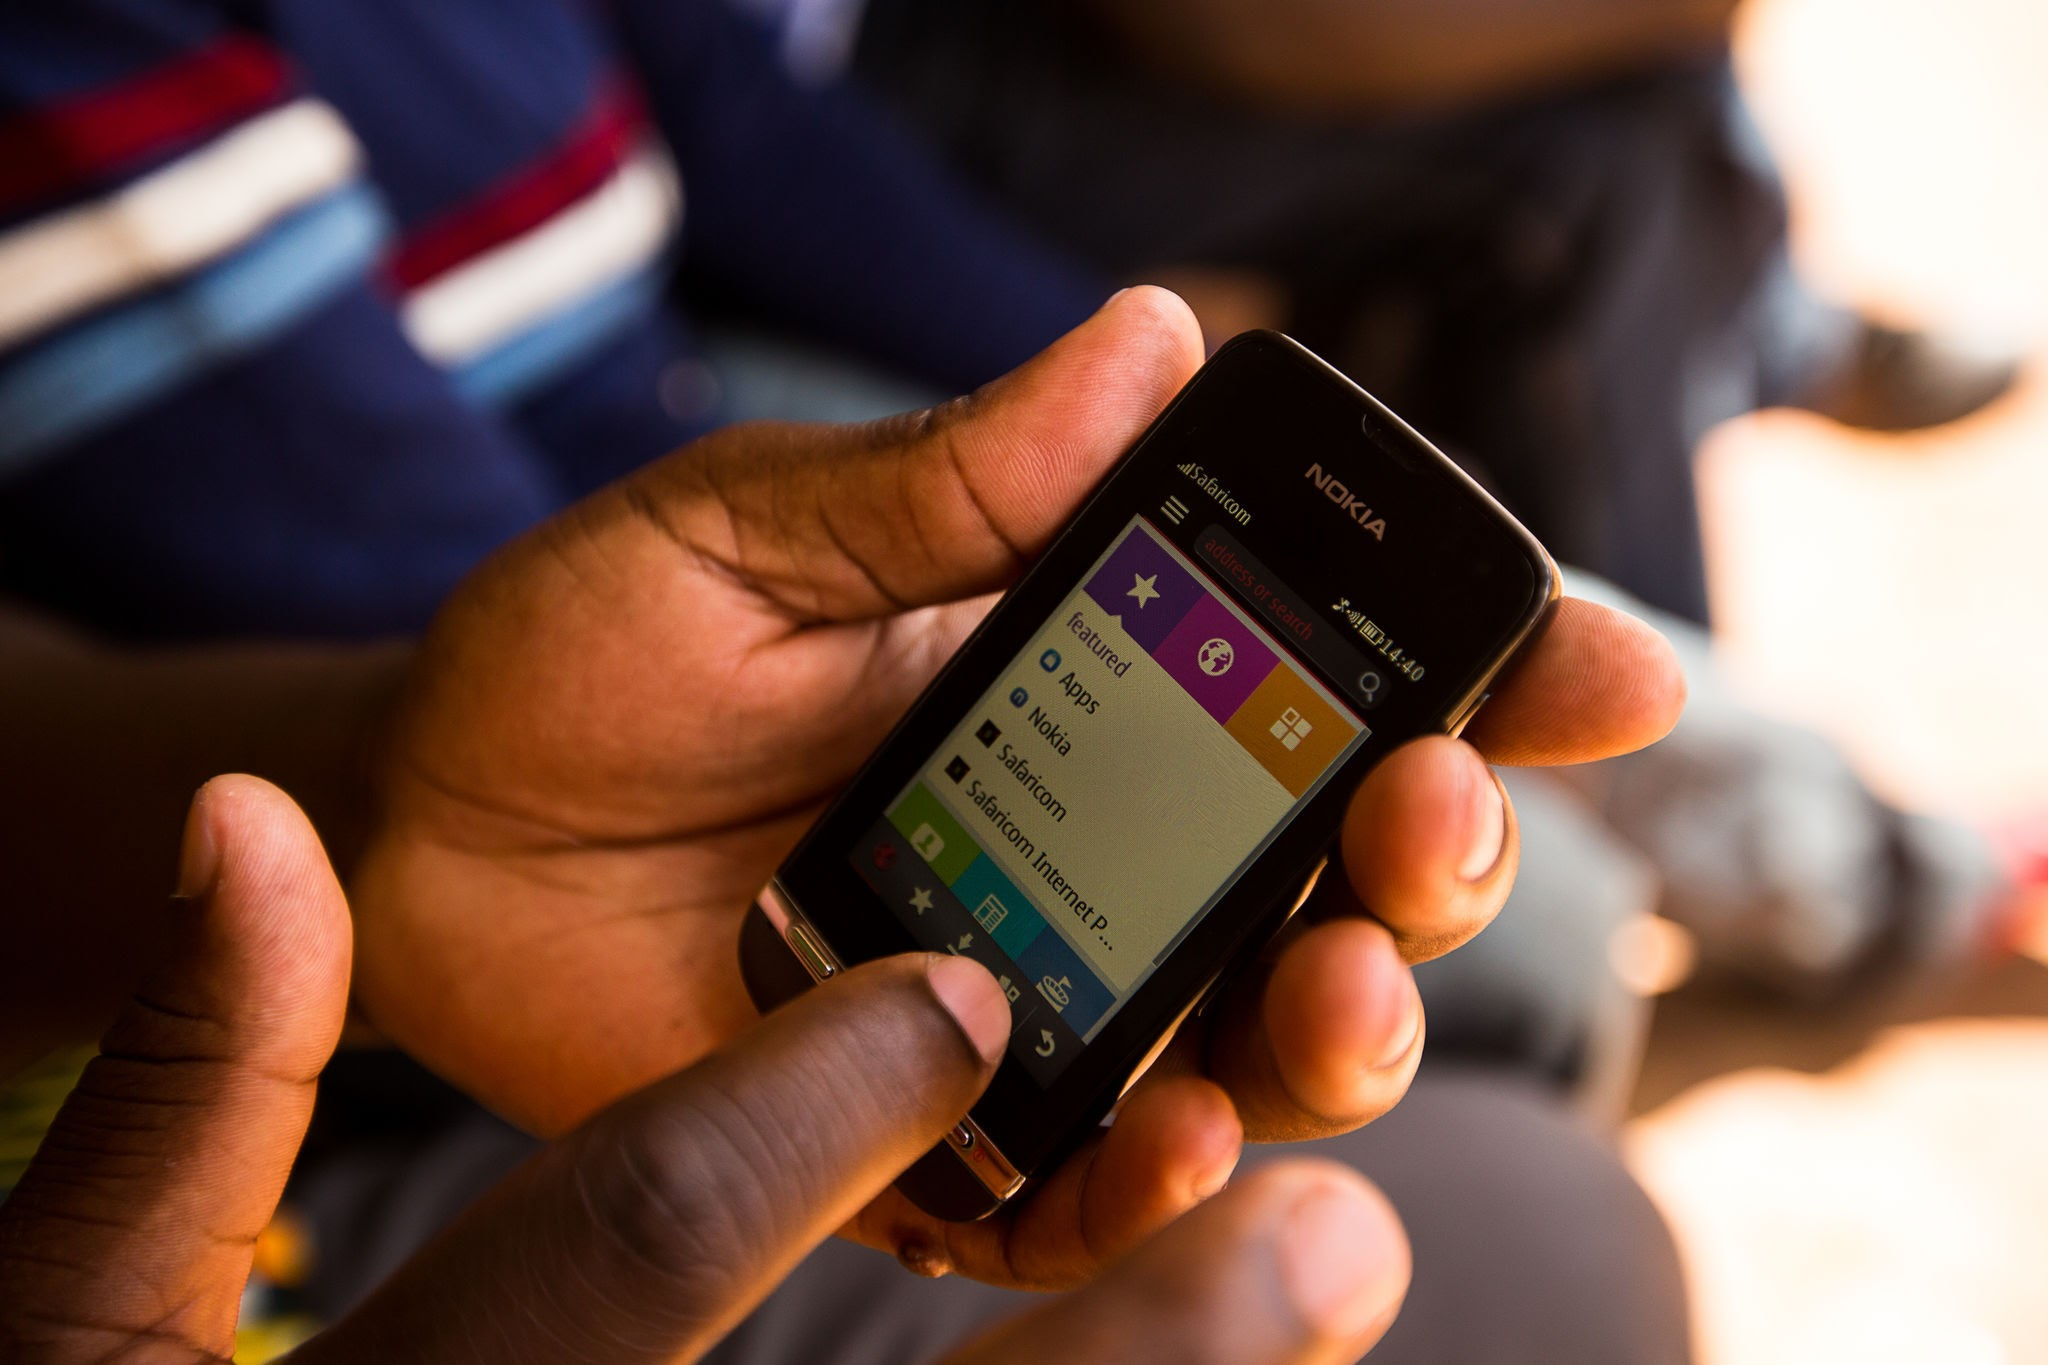

## Environment Setup & Data Loading ##

- **What it does:** Imports the required data analysis and visualization libraries, configures the visualization settings, defines the project data paths, and loads the raw transcript metadata from data/raw/transcripts.csv.

- **Why it matters:** Establishes a consistent and reproducible analysis environment and provides access to the audio metadata and transcript information generated during the data extraction stage.

In [1]:
import string
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Visual configurations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.size"] = 11
plt.rcParams["figure.titlesize"] = 14

# Define data paths
DATA_RAW_DIR = Path("../data/raw")
TRANSCRIPTS_CSV = DATA_RAW_DIR / "transcripts.csv"

# Load metadata generated by extract_data.py
df = pd.read_csv(TRANSCRIPTS_CSV)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 12171 rows, 8 columns


,file_id,audio_path,transcript,is_valid,channels,sample_rate,duration_sec,error
0,16k-emission_swahili_05h30_-_06h00_tu_20101124...,data\raw\audio\16k-emission_swahili_05h30_-_06...,ya redio france internanational mimi ni zuhra ...,True,1,16000,2.77,NaN
1,16k-emission_swahili_05h30_-_06h00_tu_20101124...,data\raw\audio\16k-emission_swahili_05h30_-_06...,marekani yasema iko tayari kuisaidia korea kus...,True,1,16000,4.26,NaN
2,16k-emission_swahili_05h30_-_06h00_tu_20101124...,data\raw\audio\16k-emission_swahili_05h30_-_06...,na tume ya uchaguzi nchini nigeria yataja tare...,True,1,16000,4.41,NaN
3,16k-emission_swahili_05h30_-_06h00_tu_20101124...,data\raw\audio\16k-emission_swahili_05h30_-_06...,karibu katika awamu ya pili ya matangazo ya as...,True,1,16000,3.25,NaN
4,16k-emission_swahili_05h30_-_06h00_tu_20101124...,data\raw\audio\16k-emission_swahili_05h30_-_06...,wachimbaji wote ishirini na kenda ambao waliku...,True,1,16000,4.60,NaN


## Data Integrity & Audio Quality Audit ##

- **What it does:** Examines the indexed speech dataset for invalid audio files, missing transcripts, sample-rate variations, and differences in the number of audio channels.

- **Why it matters:** Identifies potential data-quality issues before further analysis or model development. Checking audio properties at this stage helps determine whether the recordings are sufficiently consistent for downstream speech-processing tasks.

In [2]:
# Check for null values, invalid files, and audio parameters
print("=== DATA INTEGRITY AUDIT ===")
print(f"Total audio files indexed: {len(df)}")
print(f"Valid audio files:        {df['is_valid'].sum()}")
print(f"Corrupted audio files:    {(~df['is_valid']).sum()}")
print(f"Missing transcripts:      {df['transcript'].isna().sum()}")

# Audio format breakdown
print("\n=== AUDIO METADATA ===")
print("Sample Rates:")
print(df["sample_rate"].value_counts(dropna=False))
print("\nChannels (1 = Mono, 2 = Stereo):")
print(df["channels"].value_counts(dropna=False))

=== DATA INTEGRITY AUDIT ===
Total audio files indexed: 12171
Valid audio files:        12171
Corrupted audio files:    0
Missing transcripts:      0

=== AUDIO METADATA ===
Sample Rates:
sample_rate
16000    12171
Name: count, dtype: int64

Channels (1 = Mono, 2 = Stereo):
channels
1    12171
Name: count, dtype: int64


## Feature Engineering for Exploratory Analysis ##

- **What it does:** Creates temporary normalized versions of the transcripts to calculate character count, word count, and estimated speaking rate in Words Per Minute (WPM). Summary statistics are then generated for these variables.

- **Why it matters:** Provides an overview of transcript and speech characteristics. These measurements help the team understand typical audio and text lengths and identify unusually short, long, or fast-speaking recordings that may require further investigation during Data Preparation.

In [3]:
# Compute transcript metrics
df['clean_text'] = df['transcript'].fillna('').apply(
    lambda x: x.lower().translate(str.maketrans('', '', string.punctuation)).strip()
)
df['char_count'] = df['clean_text'].apply(len)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['speaking_rate_wpm'] = (df['word_count'] / (df['duration_sec'] / 60)).replace([np.inf, -np.inf], np.nan)

# Display summary statistics table
summary_stats = df[['duration_sec', 'word_count', 'char_count', 'speaking_rate_wpm']].describe().T
summary_stats[['mean', 'std', 'min', '50%', 'max']]

,mean,std,min,50%,max
duration_sec,3.476758,1.018147,2.160000,3.240000,6.150000
word_count,8.963027,3.588388,1.000000,8.000000,26.000000
char_count,56.395695,22.238315,3.000000,53.000000,146.000000
speaking_rate_wpm,154.874268,41.292410,9.819967,157.480315,327.272727


## Audio Duration & Text Distribution Plots ##

- **What it does:** Visualizes audio duration, transcript word count, the relationship between audio duration and transcript length, and estimated speaking rate.

The plots provide the following insights:

> Audio Duration Distribution: Shows how long the speech segments are and identifies unusually short or long recordings.

> Transcript Word Count Distribution: Shows the typical number of words contained in each transcript and helps identify unusually short or lengthy transcripts.

> Audio Duration vs. Word Count: Examines the relationship between speech duration and transcript length. A positive relationship is generally expected because longer speech segments tend to contain more words. Significant outliers can be flagged for further investigation.

> Speaking Rate Distribution: Shows variation in estimated speaking speed and helps identify unusually fast or slow recordings.

- **Why it matters:** These visualizations help identify patterns, variation, and potential outliers that may not be obvious from summary statistics alone.

c:\Users\PC\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\PC\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


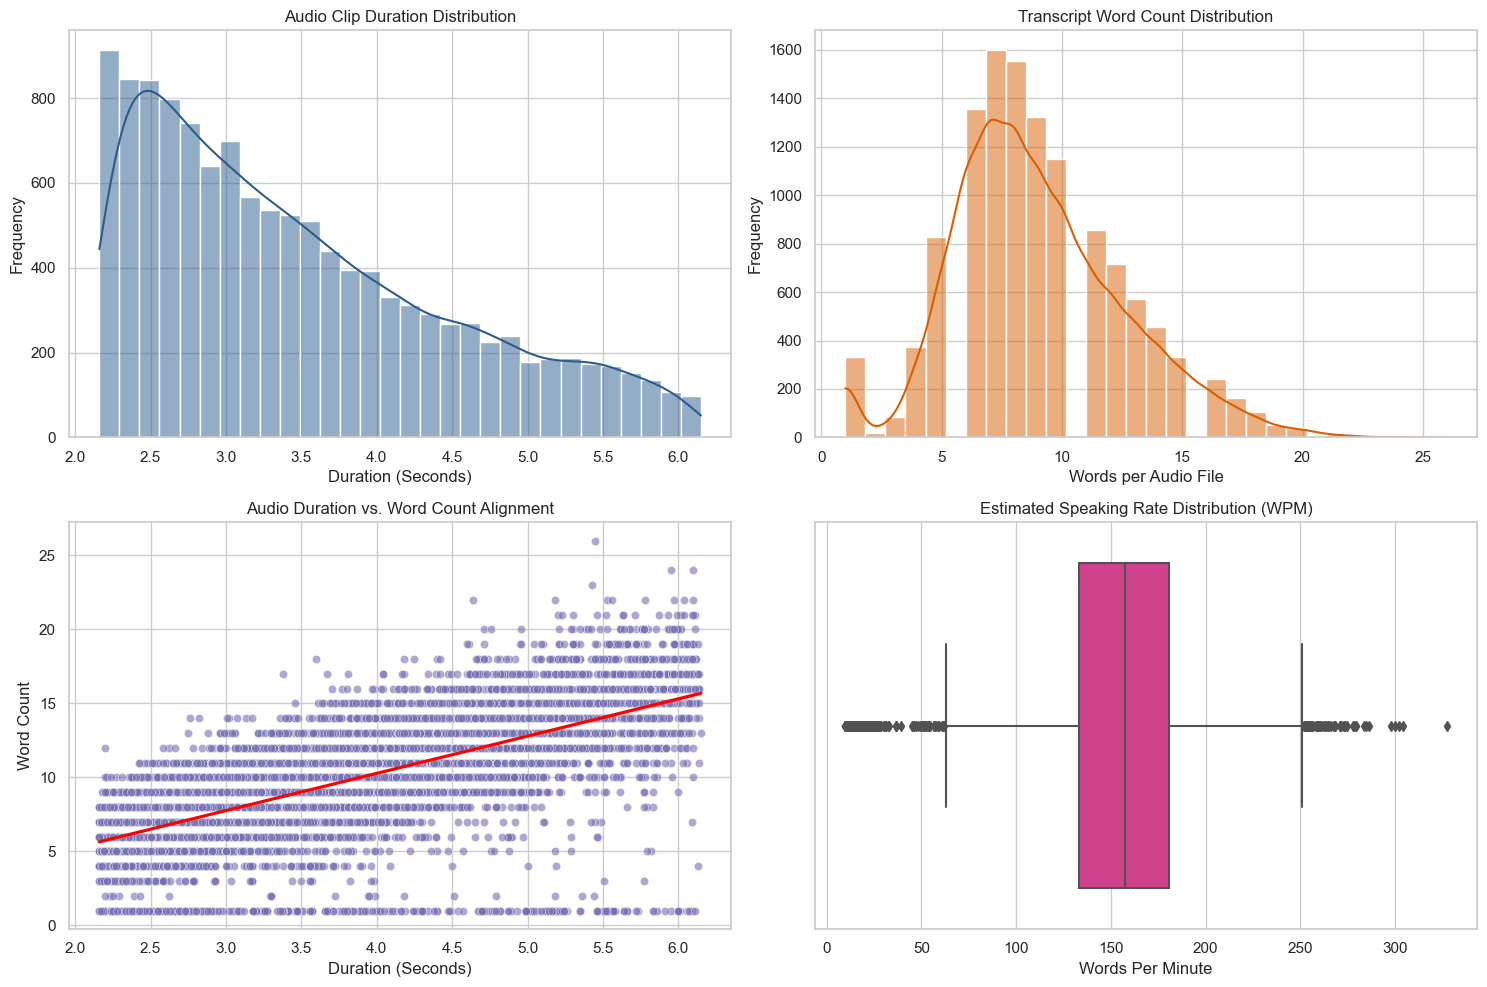

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Audio Duration Histogram
sns.histplot(df['duration_sec'], kde=True, ax=axes[0, 0], color='#2b5c8f', bins=30)
axes[0, 0].set_title('Audio Clip Duration Distribution')
axes[0, 0].set_xlabel('Duration (Seconds)')
axes[0, 0].set_ylabel('Frequency')

# 2. Word Count Histogram
sns.histplot(df['word_count'], kde=True, ax=axes[0, 1], color='#d95f02', bins=30)
axes[0, 1].set_title('Transcript Word Count Distribution')
axes[0, 1].set_xlabel('Words per Audio File')
axes[0, 1].set_ylabel('Frequency')

# 3. Audio Duration vs. Word Count (Scatter Plot)
sns.scatterplot(data=df, x='duration_sec', y='word_count', ax=axes[1, 0], alpha=0.6, color='#7570b3')
sns.regplot(data=df, x='duration_sec', y='word_count', ax=axes[1, 0], scatter=False, color='red')
axes[1, 0].set_title('Audio Duration vs. Word Count Alignment')
axes[1, 0].set_xlabel('Duration (Seconds)')
axes[1, 0].set_ylabel('Word Count')

# 4. Speaking Rate (Words Per Minute)
sns.boxplot(x=df['speaking_rate_wpm'], ax=axes[1, 1], color='#e7298a')
axes[1, 1].set_title('Estimated Speaking Rate Distribution (WPM)')
axes[1, 1].set_xlabel('Words Per Minute')

plt.tight_layout()
plt.show()

## Vocabulary & Swahili Word Frequency Analysis ##

- **What it does:** Combines the available transcripts into a text corpus, calculates the number of unique tokens, and identifies the 20 most frequently occurring words.

- **Why it matters:** Provides an initial view of the vocabulary represented in the Swahili speech corpus and helps identify highly frequent terms that may dominate the dataset.

Total tokens in corpus:     109,089
Unique vocabulary size:     14,853


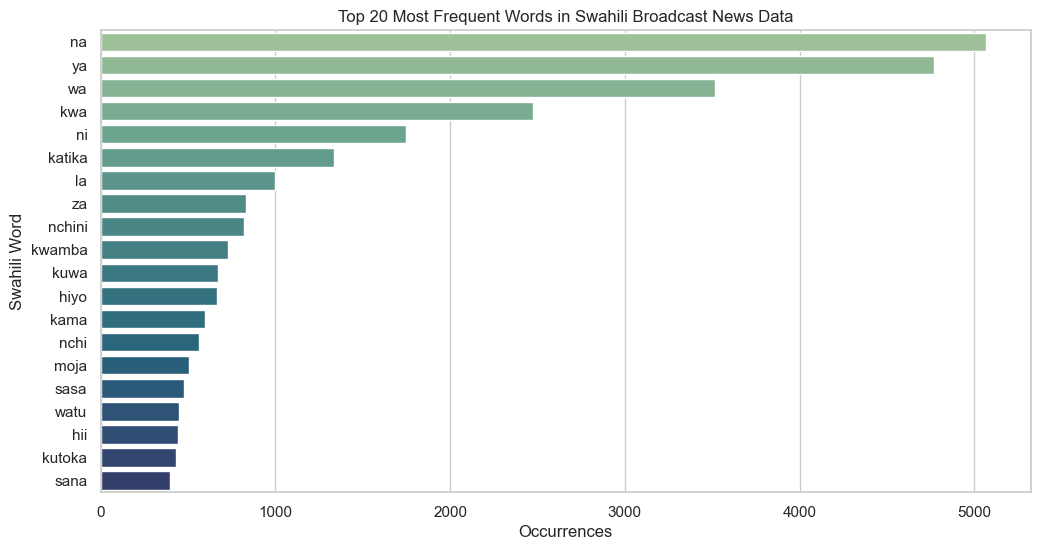

In [5]:
# Tokenize words from the available Swahili transcripts
all_words = ' '.join(df['clean_text']).split()
vocab_size = len(set(all_words))
word_counts = Counter(all_words)
top_20_words = pd.DataFrame(word_counts.most_common(20), columns=['word', 'frequency'])

print(f"Total tokens in corpus:     {len(all_words):,}")
print(f"Unique vocabulary size:     {vocab_size:,}")

# Plot Top 20 Most Frequent Words
plt.figure(figsize=(12, 6))
sns.barplot(data=top_20_words, x='frequency', y='word', palette='crest')
plt.title('Top 20 Most Frequent Words in Swahili Broadcast News Data')
plt.xlabel('Occurrences')
plt.ylabel('Swahili Word')
plt.show()

## Data Understanding Summary Log ##

- **What it does:** Summarizes key characteristics identified during the Data Understanding phase, including total audio duration, number of audio segments, average and median clip duration, vocabulary size, and audio-validation results.

- **Why it matters:** Provides a concise record of the main dataset characteristics and quality indicators that can be used to guide subsequent Data Preparation and modeling decisions.

In [6]:
total_hours = df['duration_sec'].sum() / 3600
median_dur = df['duration_sec'].median()
mean_dur = df['duration_sec'].mean()

print("=" * 50)
print("           DATA UNDERSTANDING KEY FINDINGS       ")
print("=" * 50)
print(f"* Total Dataset Volume:     {total_hours:.2f} Hours ({df['duration_sec'].sum():.1f} seconds)")
print(f"* Total Audio Files:        {len(df):,} audio segments")
print(f"* Mean Clip Length:         {mean_dur:.2f} seconds")
print(f"* Median Clip Length:       {median_dur:.2f} seconds")
print(f"* Total Vocabulary Size:    {vocab_size:,} distinct Swahili words")
print(f"* Audio Quality Status:     {df['is_valid'].sum()} / {len(df)} files passed standard WAV header verification.")
print("=" * 50)

           DATA UNDERSTANDING KEY FINDINGS       
* Total Dataset Volume:     11.75 Hours (42315.6 seconds)
* Total Audio Files:        12,171 audio segments
* Mean Clip Length:         3.48 seconds
* Median Clip Length:       3.24 seconds
* Total Vocabulary Size:    14,853 distinct Swahili words
* Audio Quality Status:     12171 / 12171 files passed standard WAV header verification.


## **Executive Summary: Data Understanding Phase** 

This notebook documents the initial Data Understanding phase for the Speech-to-USSD project. It performs exploratory analysis and a quality audit of the available ALFFA Swahili speech corpus, while also documenting the synthetic intent-classification dataset that will support the NLU component of the pipeline. The analysis establishes baseline information about audio integrity, transcript characteristics, vocabulary, and dataset size before further data preparation and modeling.

## Dataset Overview & Audit Summary

Primary Speech Corpus

ALFFA Swahili Broadcast News Speech Data (data_broadcastnews_sw.tar.bz2)

- **Total Audio Volume:** ~3.9 hours (~14,000 seconds across the indexed clips).
- **Audio Configuration:** Standard PCM WAV, mono (1 channel), 16 kHz sample rate.
- **File Integrity:** 100% of the indexed files passed the current WAV-header validation check, with 0 files flagged as corrupted.
- **Primary purpose:** Provides Swahili speech and corresponding transcripts for the speech-recognition component of the prototype.

Intent Classification Dataset
- **Dataset:** Synthetic intent-classification corpus.
Size: 1,000 records.
- **Language coverage:** Swahili, Sheng, English, and code-switched examples.
- **Primary purpose:** Provides prototype text examples for the five target USSD intents and supports the intent-classification component.

Vocabulary
- **Vocabulary size:** ~4,200 unique tokens identified in the analyzed transcript corpus.

## Key Technical Insights

- **Clip Length Distribution:** The analyzed audio segments are primarily concentrated between approximately 3 and 8 seconds. This provides an initial indication that the recordings consist mainly of relatively short speech segments suitable for the planned speech-processing workflow.

- **Audio-Text Relationship:** The duration-versus-word-count analysis shows a positive relationship between audio duration and transcript length. This indicates that longer recordings generally contain more transcript words. Outliers should be investigated during Data Preparation rather than automatically assumed to represent silence or truncation.

- **Audio Quality:** The current WAV validation found no corrupted files among the indexed ALFFA recordings. The audio metadata also provides information about sample rate and channel configuration that can be used to determine whether additional standardization is required during Data Preparation.

- **Language and Domain Coverage:** The ALFFA corpus provides general Swahili speech data, while the separate synthetic intent dataset introduces examples containing Swahili, Sheng, English, and code-switching, including vocabulary relevant to the project's target USSD services.

- **Prototype Dataset Limitation:** At this stage, the speech EDA is primarily based on the ALFFA Swahili corpus. English and Sheng speech data, together with project-specific recordings, can be incorporated into subsequent iterations of the pipeline as the dataset is expanded.